# Anomaly Detection

We will implement the anomaly detection algorithm and apply it to detect failing servers on a network. 



# Outline
- [ 1 - Packages ](#1)
- [ 2 - Anomaly detection](#2)
  - [ 2.1 Problem Statement](#2.1)
  - [ 2.2  Dataset](#2.2)
  - [ 2.3 Gaussian distribution](#2.3)
    - [ Exercise 1](#ex01)
    - [ Exercise 2](#ex02)
  - [ 2.4 High dimensional dataset](#2.4)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

%matplotlib inline

<a name="2"></a>
## 2 - Anomaly detection

<a name="2.1"></a>
### 2.1 Problem Statement

In this exercise, you will implement an anomaly detection algorithm to
detect anomalous behavior in server computers.

The dataset contains two features - 
   * throughput (mb/s) and 
   * latency (ms) of response of each server.

While your servers were operating, you collected $m=307$ examples of how they were behaving, and thus have an unlabeled dataset $\{x^{(1)}, \ldots, x^{(m)}\}$. 
* You suspect that the vast majority of these examples are “normal” (non-anomalous) examples of the servers operating normally, but there might also be some examples of servers acting anomalously within this dataset.

You will use a Gaussian model to detect anomalous examples in your
dataset. 
* You will first start on a 2D dataset that will allow you to visualize what the algorithm is doing.
* On that dataset you will fit a Gaussian distribution and then find values that have very low probability and hence can be considered anomalies. 
* After that, you will apply the anomaly detection algorithm to a larger dataset with many dimensions. 

<a name="2.2"></a>
### 2.2  Dataset

You will start by loading the dataset for this task. 
- The `load_data()` function shown below loads the data into the variables `X_train`, `X_val` and `y_val` 
    - You will use `X_train` to fit a Gaussian distribution 
    - You will use `X_val` and `y_val` as a cross validation set to select a threshold and determine anomalous vs normal examples

In [2]:
# Load the dataset
X_train, X_val, y_val = load_data()

In [3]:
# Display the first 10 examples from the training set
print("First 10 training examples:\n", X_train[:10])

First 10 training examples:
 [[13.04681517 14.74115241]
 [13.40852019 13.7632696 ]
 [14.19591481 15.85318113]
 [14.91470077 16.17425987]
 [13.57669961 14.04284944]
 [13.92240251 13.40646894]
 [12.82213164 14.22318782]
 [15.67636615 15.89169137]
 [16.16287532 16.20299807]
 [12.66645095 14.89908374]]


In [4]:
# Display the first 10 elements of the X_val
print("First 10 validation examples:\n", X_val[:10])

First 10 validation examples:
 [[15.79025979 14.9210243 ]
 [13.63961877 15.32995521]
 [14.86589943 16.47386514]
 [13.58467605 13.98930611]
 [13.46404167 15.63533011]
 [12.94888838 16.14006828]
 [15.31084155 15.17480137]
 [13.89795241 15.43169469]
 [11.92096525 14.30579937]
 [14.85934119 14.90066474]]


In [5]:
# Display the first 10 elements of the y_val
print("First 10 validation labels:\n", y_val[:10])

First 10 validation labels:
 [0 0 0 0 0 0 0 0 0 1]


#### Check the dimensions of your variables

Another useful way to get familiar with your data is to view its dimensions.

The code below prints the shape of `X_train`, `X_val` and `y_val`.

In [6]:
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape) 
print("Validation labels shape:", y_val.shape)

Training set shape: (307, 2)
Validation set shape: (307, 2)
Validation labels shape: (307,)


#### Visualize your data

Before starting on any task, it is often useful to understand the data by visualizing it. 
- For this dataset, you can use a scatter plot to visualize the data (`X_train`), since it has only two properties to plot (throughput and latency)

- Your plot should look similar to the one below
<img src="images/figure1.png" width="500" height="500">

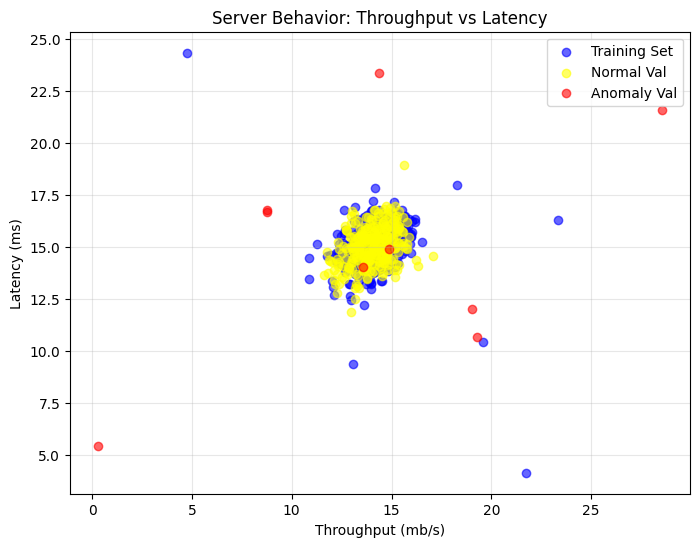

In [7]:
# Create scatter plot
plt.figure(figsize=(8, 6))

# Plot training examples
plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', label='Training Set', alpha=0.6)

# Plot validation examples, coloring anomalies (y_val=1) in red and normal (y_val=0) in yellow
plt.scatter(X_val[y_val==0, 0], X_val[y_val==0, 1], c='yellow', label='Normal Val', alpha=0.6)
plt.scatter(X_val[y_val==1, 0], X_val[y_val==1, 1], c='red', label='Anomaly Val', alpha=0.6)

# Add labels and title
plt.xlabel('Throughput (mb/s)')
plt.ylabel('Latency (ms)')
plt.title('Server Behavior: Throughput vs Latency')
plt.legend()

# Show grid
plt.grid(True, alpha=0.3)
plt.show()

<a name="2.3"></a>
### 2.3 Gaussian distribution

To perform anomaly detection, you will first need to fit a model to the data’s distribution.

* Given a training set $\{x^{(1)}, ..., x^{(m)}\}$ you want to estimate the Gaussian distribution for each
of the features $x_i$. 

* Recall that the Gaussian distribution is given by

   $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

   where $\mu$ is the mean and $\sigma^2$ is the variance.
   
* For each feature $i = 1\ldots n$, you need to find parameters $\mu_i$ and $\sigma_i^2$ that fit the data in the $i$-th dimension $\{x_i^{(1)}, ..., x_i^{(m)}\}$ (the $i$-th dimension of each example).

### 2.3.1 Estimating parameters for a Gaussian distribution

**Implementation**: 
We will `estimate_gaussian` function below to calculate `mu` (mean for each feature in `X`) and `var` (variance for each feature in `X`). 

You can estimate the parameters, ($\mu_i$, $\sigma_i^2$), of the $i$-th
feature by using the following equations. To estimate the mean, you will
use:

$$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

and for the variance you will use:
$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

In [8]:
def estimate_gaussian(X):
    """
    Estimate the parameters of a Gaussian distribution using the data in X.
    
    Parameters:
    X : array_like, shape (m, n)
        The input data where m is the number of examples and n is the number of features.
        
    Returns:
    mu : array_like, shape (n,)
        The mean of each feature.
    var : array_like, shape (n,)
        The variance of each feature.
    """
    m, n = X.shape
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    
    return mu, var  

In [9]:
# We will visualize the contours of the Gaussian distribution
def visualize_gaussian(mu, var): 
    """
    Visualize the Gaussian distribution contours.
    
    Parameters:
    mu : array_like, shape (n,)
        The mean of each feature.
    var : array_like, shape (n,)
        The variance of each feature.
    """
    x = np.linspace(mu[0] - 3 * np.sqrt(var[0]), mu[0] + 3 * np.sqrt(var[0]), 100)
    y = np.linspace(mu[1] - 3 * np.sqrt(var[1]), mu[1] + 3 * np.sqrt(var[1]), 100)
    X, Y = np.meshgrid(x, y)
    
    Z = (1 / (2 * np.pi * np.sqrt(var[0] * var[1]))) * \
        np.exp(-((X - mu[0])**2 / (2 * var[0]) + (Y - mu[1])**2 / (2 * var[1])))
    
    plt.contour(X, Y, Z, levels=10)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Gaussian Distribution Contours')
    plt.show()

In [10]:
mu, var = estimate_gaussian(X_train)
print("Estimated Mean:\n", mu)
print("Estimated Variance:\n", var)

Estimated Mean:
 [14.11222578 14.99771051]
Estimated Variance:
 [1.83263141 1.70974533]


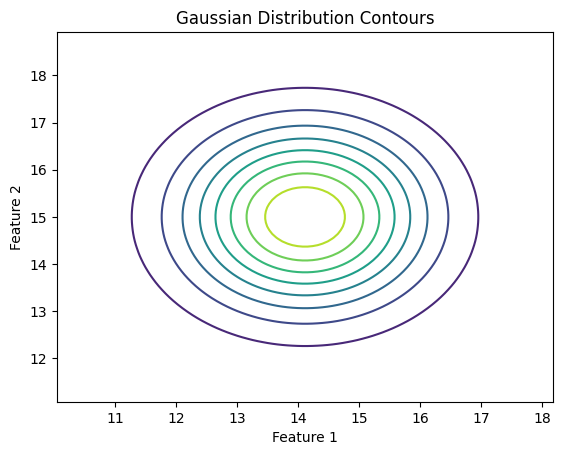

In [11]:
visualize_gaussian(*estimate_gaussian(X_train)) 


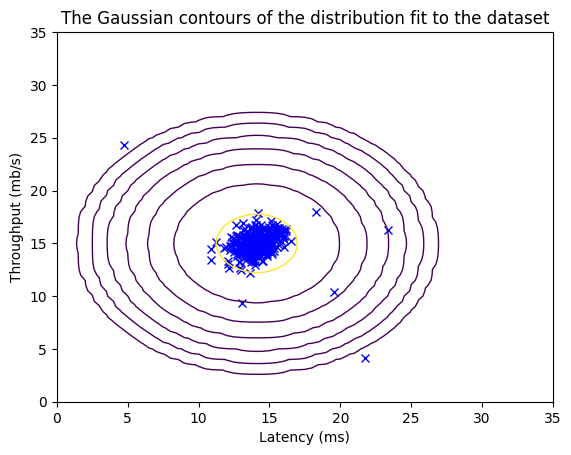

In [12]:
p = multivariate_gaussian(X_train, *estimate_gaussian(X_train))
visualize_fit(X_train, mu, var)

### 2.3.2 Selecting the threshold $\epsilon$

Now that you have estimated the Gaussian parameters, you can investigate which examples have a very high probability given this distribution and which examples have a very low probability.  

* The low probability examples are more likely to be the anomalies in our dataset. 
* One way to determine which examples are anomalies is to select a threshold based on a cross validation set. 

In this section, you will complete the code in `select_threshold` to select the threshold $\varepsilon$ using the $F_1$ score on a cross validation set.

* For this, we will use a cross validation set
$\{(x_{\rm cv}^{(1)}, y_{\rm cv}^{(1)}),\ldots, (x_{\rm cv}^{(m_{\rm cv})}, y_{\rm cv}^{(m_{\rm cv})})\}$, where the label $y=1$ corresponds to an anomalous example, and $y=0$ corresponds to a normal example. 
* For each cross validation example, we will compute $p(x_{\rm cv}^{(i)})$. The vector of all of these probabilities $p(x_{\rm cv}^{(1)}), \ldots, p(x_{\rm cv}^{(m_{\rm cv})})$ is passed to `select_threshold` in the vector `p_val`. 
* The corresponding labels $y_{\rm cv}^{(1)}, \ldots, y_{\rm cv}^{(m_{\rm cv})}$ are passed to the same function in the vector `y_val`.

<a name="ex02"></a>

We will the complete the `select_threshold` function below to find the best threshold to use for selecting outliers based on the results from the validation set (`p_val`) and the ground truth (`y_val`). 

* In the provided code `select_threshold`, there is already a loop that will try many different values of $\varepsilon$ and select the best $\varepsilon$ based on the $F_1$ score. 

* You need to implement code to calculate the F1 score from choosing `epsilon` as the threshold and place the value in `F1`. 

  * Recall that if an example $x$ has a low probability $p(x) < \varepsilon$, then it is classified as an anomaly. 
        
  * Then, you can compute precision and recall by: 
  $$\begin{aligned}
   prec&=&\frac{tp}{tp+fp}\\
   rec&=&\frac{tp}{tp+fn},
   \end{aligned}$$ 
   where
  * $tp$ is the number of true positives: the ground truth label says it’s an anomaly and our algorithm correctly 
  classified it as an anomaly.
  * $fp$ is the number of false positives: the ground truth label says it’s not an anomaly, but our algorithm 
  incorrectly classified it as an anomaly.
  * $fn$ is the number of false negatives: the ground truth label says it’s an anomaly, but our algorithm 
  incorrectly classified it as not being anomalous.

  * The $F_1$ score is computed using precision ($prec$) and recall ($rec$) as follows:
    $$F_1 = \frac{2\cdot prec \cdot rec}{prec + rec}$$ 

**Implementation Note:** 
In order to compute $tp$, $fp$ and $fn$, you may be able to use a vectorized implementation rather than loop over all the examples.

In [13]:
def select_threshold(y_val, p):
    """
    Select the best threshold for anomaly detection.
    
    Parameters:
    y_val : array_like, shape (m,)
        The true labels for the validation set.
    p : array_like, shape (m,)
        The predicted probabilities of anomalies.
        
    Returns:
    best_epsilon : float
        The best threshold for anomaly detection.
    best_f1 : float
        The best F1 score achieved with the threshold.
    """
    best_epsilon = 0
    best_f1 = 0
    step_size = (np.max(p) - np.min(p)) / 1000
    
    for epsilon in np.arange(np.min(p), np.max(p), step_size):
        predictions = (p < epsilon).astype(int)
        
        tp = np.sum((predictions == 1) & (y_val == 1))
        fp = np.sum((predictions == 1) & (y_val == 0))
        fn = np.sum((predictions == 0) & (y_val == 1))
        
        if tp + fp > 0 and tp + fn > 0:
            precision = tp / (tp + fp)
            recall = tp / (tp + fn)
            f1 = (2 * precision * recall) / (precision + recall)
            
            if f1 > best_f1:
                best_f1 = f1
                best_epsilon = epsilon
                
    return best_epsilon, best_f1

In [14]:
p_val = multivariate_gaussian(X_val, mu, var)
best_epsilon, best_f1 = select_threshold(y_val, p_val)
print("Best epsilon found using cross validation:", best_epsilon)
print("Best F1 score on cross validation:", best_f1)

Best epsilon found using cross validation: 8.990852779269495e-05
Best F1 score on cross validation: 0.8750000000000001


Number of outliers detected in the training set: 6


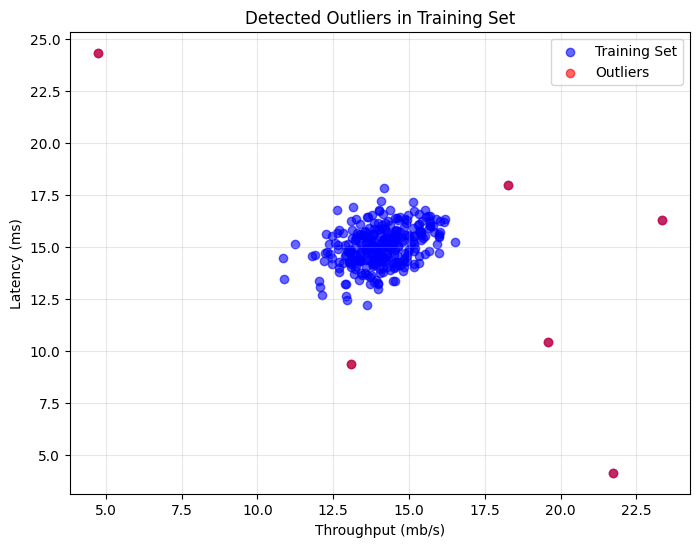

In [15]:
# Find the outliers in the training set
outliers = (p < best_epsilon).astype(int)
print("Number of outliers detected in the training set:", np.sum(outliers))
# Visualize the outliers
plt.figure(figsize=(8, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', label='Training Set', alpha=0.6)
plt.scatter(X_train[outliers==1, 0], X_train[outliers==1, 1], c='red', label='Outliers', alpha=0.6)
plt.xlabel('Throughput (mb/s)')
plt.ylabel('Latency (ms)')
plt.title('Detected Outliers in Training Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()  

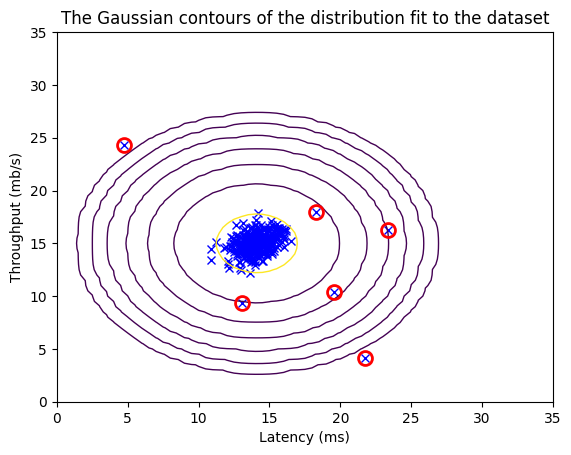

In [16]:
# Find the outliers in the training set 
outliers = p < best_epsilon

# Visualize the fit
visualize_fit(X_train, mu, var)

# Draw a red circle around those outliers
plt.plot(X_train[outliers, 0], X_train[outliers, 1], 'ro',
         markersize= 10,markerfacecolor='none', markeredgewidth=2)

<a name="2.4"></a>
### 2.4 High dimensional dataset

Now,  we will run the anomaly detection algorithm that you implemented on a more realistic and much harder dataset.

In this dataset, each example is described by 11 features, capturing many more properties of your compute servers.

Let's start by loading the dataset.

- The `load_data()` function shown below loads the data into variables `X_train_high`, `X_val_high` and `y_val_high`
    -  `_high` is meant to distinguish these variables from the ones used in the previous part
    - We will use `X_train_high` to fit Gaussian distribution 
    - We will use `X_val_high` and `y_val_high` as a cross validation set to select a threshold and determine anomalous vs normal examples

In [17]:
# load the dataset
X_train_high, X_val_high, y_val_high = load_data_multi()

In [18]:
print ('The shape of X_train_high is:', X_train_high.shape)
print ('The shape of X_val_high is:', X_val_high.shape)
print ('The shape of y_val_high is: ', y_val_high.shape)

The shape of X_train_high is: (1000, 11)
The shape of X_val_high is: (100, 11)
The shape of y_val_high is:  (100,)


#### Anomaly detection 

Now, let's run the anomaly detection algorithm on this new dataset.

The code below will use your code to 
* Estimate the Gaussian parameters ($\mu_i$ and $\sigma_i^2$)
* Evaluate the probabilities for both the training data `X_train_high` from which you estimated the Gaussian parameters, as well as for the the cross-validation set `X_val_high`. 
* Finally, it will use `select_threshold` to find the best threshold $\varepsilon$. 

In [19]:
# Apply the same steps to the larger dataset

# Estimate the Gaussian parameters
mu_high, var_high = estimate_gaussian(X_train_high)

# Evaluate the probabilites for the training set
p_high = multivariate_gaussian(X_train_high, mu_high, var_high)

# Evaluate the probabilites for the cross validation set
p_val_high = multivariate_gaussian(X_val_high, mu_high, var_high)

# Find the best threshold
epsilon_high, F1_high = select_threshold(y_val_high, p_val_high)

print('Best epsilon found using cross-validation: %e'% epsilon_high)
print('Best F1 on Cross Validation Set:  %f'% F1_high)
print('# Anomalies found: %d'% sum(p_high < epsilon_high))

Best epsilon found using cross-validation: 1.377229e-18
Best F1 on Cross Validation Set:  0.615385
# Anomalies found: 117
